# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__

## Tutorial 17: Multi Assets Algorithmic Trading Backtesting with Vectorbt

## 1. Downloading the data:

In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime

import vectorbt as vbt # version=0.26.1
from vectorbt.portfolio.nb import order_nb, sort_call_seq_nb
from vectorbt.portfolio.enums import SizeType, Direction

import warnings

warnings.filterwarnings("ignore")

# Date range
start = '2010-01-01'
end = '2024-06-30'

# Tickers of assets
assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SHW', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Close', slice(None))]
data.columns = assets

display(data.head())

[*********************100%***********************]  25 of 25 completed


,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,105.870003,56.180000,31.662140,25.629999,7.952202,14.52,33.869999,56.060001,23.819256,18.879391,...,6.094303,24.406668,80.129997,20.556667,21.586103,48.549999,47.500000,19.040001,31.212946,13.33
2010-01-05,107.120003,58.020000,31.444866,25.230000,7.844424,14.41,33.930000,55.849998,23.919165,18.785694,...,6.078585,24.846666,80.790001,20.070000,21.480364,48.730000,47.660000,18.680000,31.269218,13.80
2010-01-06,108.800003,59.779999,31.553505,25.219999,7.788191,14.27,33.549999,55.700001,23.696638,18.723232,...,6.007859,25.173332,80.300003,19.806667,20.853474,49.660000,48.110001,19.330000,29.937416,15.00
2010-01-07,107.150002,62.200001,32.064095,25.240000,7.952202,14.41,33.040001,56.099998,23.705723,18.858568,...,5.933202,25.506666,80.190002,19.983334,20.619335,50.270000,48.110001,20.190001,29.759218,16.68
2010-01-08,106.589996,61.599998,32.140141,24.820000,7.928772,14.24,32.830002,57.630001,23.882833,18.921032,...,5.901768,25.540001,78.730003,20.153334,20.468279,50.070000,48.919998,20.379999,29.777975,16.41


## 2 Building the Backtest Function with Backtrader 

### 2.1 Building Auxiliary Functions for Rebalancing

In [2]:
vbt.settings.returns['year_freq'] = '252 days'

num_tests = 2000
ann_factor = data.vbt.returns(freq='D').ann_factor

def pre_sim_func_nb(sc, every_nth):
    # Define rebalancing days
    sc.segment_mask[:, :] = False
    sc.segment_mask[every_nth::every_nth, :] = True
    return ()


def pre_segment_func_nb(sc, find_weights_nb, rm, history_len, ann_factor, num_tests, srb_sharpe):
    if history_len == -1:
        # Look back at the entire time period
        close = sc.close[:sc.i, sc.from_col:sc.to_col]
    else:
        # Look back at a fixed time period
        if sc.i - history_len <= 0:
            return (np.full(sc.group_len, np.nan),)  # insufficient data
        close = sc.close[sc.i - history_len:sc.i, sc.from_col:sc.to_col]
    
    # Find optimal weights
    best_sharpe_ratio, weights = find_weights_nb(sc, rm, close, num_tests)
    srb_sharpe[sc.i] = best_sharpe_ratio
        
    # Update valuation price and reorder orders
    size_type = np.full(sc.group_len, SizeType.TargetPercent)
    direction = np.full(sc.group_len, Direction.LongOnly)
    temp_float_arr = np.empty(sc.group_len, dtype=np.float64)
    for k in range(sc.group_len):
        col = sc.from_col + k
        sc.last_val_price[col] = sc.close[sc.i, col]
    sort_call_seq_nb(sc, weights, size_type, direction, temp_float_arr)
    
    return (weights,)


def order_func_nb(oc, weights):
    col_i = oc.call_seq_now[oc.call_idx]
    return order_nb(
        weights[col_i], 
        oc.close[oc.i, oc.col],
        size_type=SizeType.TargetPercent, 
    )

### 2.2 Building the Optimization Function

In [3]:
import riskfolio as rp

def opt_weights(sc, rm, close, num_tests):
    # Calculate expected returns and sample covariance matrix
    close = pd.DataFrame(close, columns=assets)
    returns = close.pct_change().dropna()

    # Building the portfolio object
    port = rp.Portfolio(returns=returns)
    # Calculating optimum portfolio

    # Select method and estimate input parameters:

    method_mu='hist' # Method to estimate expected returns based on historical data.
    method_cov='hist' # Method to estimate covariance matrix based on historical data.

    port.assets_stats(method_mu=method_mu, method_cov=method_cov)

    # Estimate optimal portfolio:
    
    port.solvers = ['MOSEK']
    model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
    rm = rm # Risk measure used, this time will be variance
    obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
    hist = True # Use historical scenarios for risk measures that depend on scenarios
    rf = 0 # Risk free rate
    l = 0 # Risk aversion factor, only useful when obj is 'Utility'

    w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)
    weights = np.ravel(w.to_numpy())
    shp = rp.Sharpe(returns=returns,
                    w=w,
                    mu=port.mu,
                    cov=port.cov,
                    rm=rm,
                    rf=0,
                    alpha=0.05,
                    solver='MOSEK')

    return shp, weights

## 3 Building Strategies with Vectorbt

### 3.1 Optimizing Portfolios each Rebalancing Date

In [4]:
%%time

# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'RLVaR': Relativistic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'CDaR': Conditional Drawdown at Risk of uncompounded returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded returns.
# 'RLDaR': Relativistic Drawdown at Risk of uncompounded returns.
# 'MDD': Maximum Drawdown of uncompounded returns (Calmar Ratio).

rms = ["MV", "CVaR", "EVaR", "RLVaR", "WR",
       "CDaR", "EDaR", "RLDaR", "MDD"]

sharpe = {}
portfolio = {}

for i in rms:
    sharpe[i] = np.full(data.shape[0], np.nan)

    # Run simulation with a custom order function (Numba should be disabled)
    portfolio[i] = vbt.Portfolio.from_order_func(
        data,
        order_func_nb,
        pre_sim_func_nb=pre_sim_func_nb,
        pre_sim_args=(30,),
        pre_segment_func_nb=pre_segment_func_nb,
        pre_segment_args=(opt_weights, i, 252*4, ann_factor, num_tests, sharpe[i]),
        cash_sharing=True, 
        group_by=True,
        use_numba=False,
    )

CPU times: user 2min 27s, sys: 8.27 s, total: 2min 35s
Wall time: 2min 29s


### 3.2 Plotting Portfolio Composition each Rebalancing Date

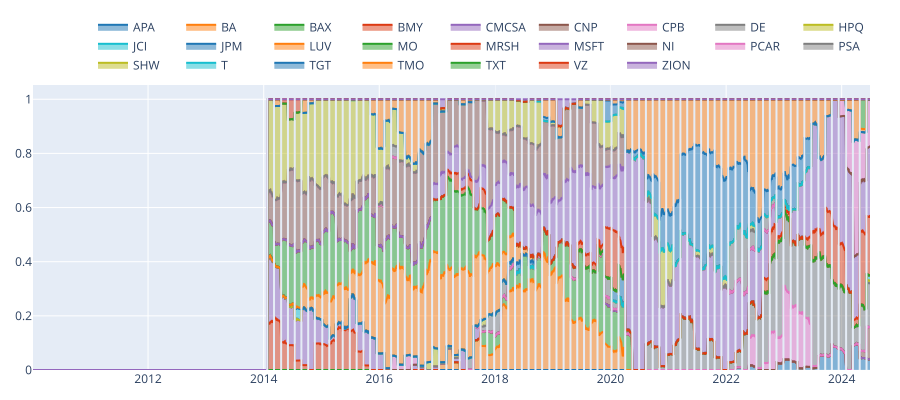

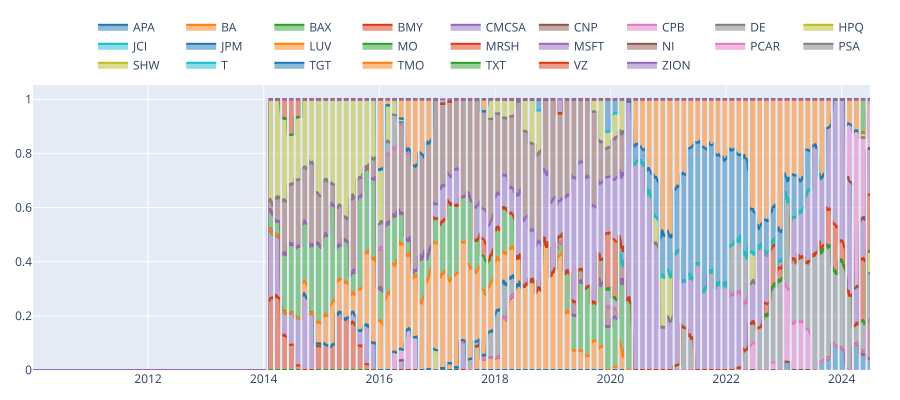

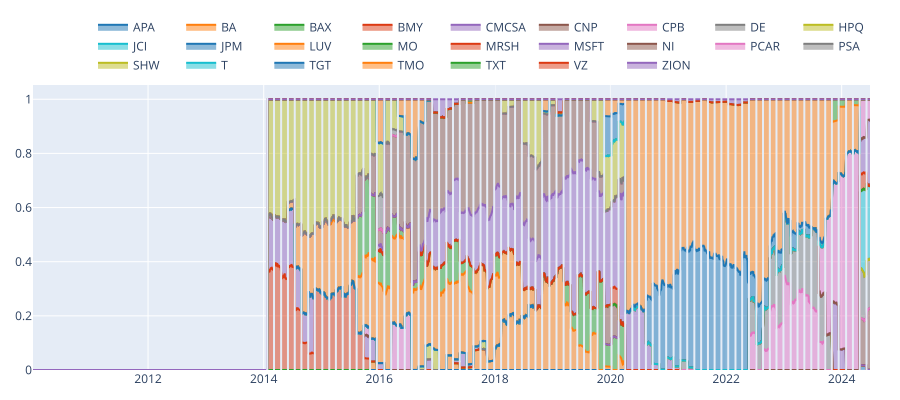

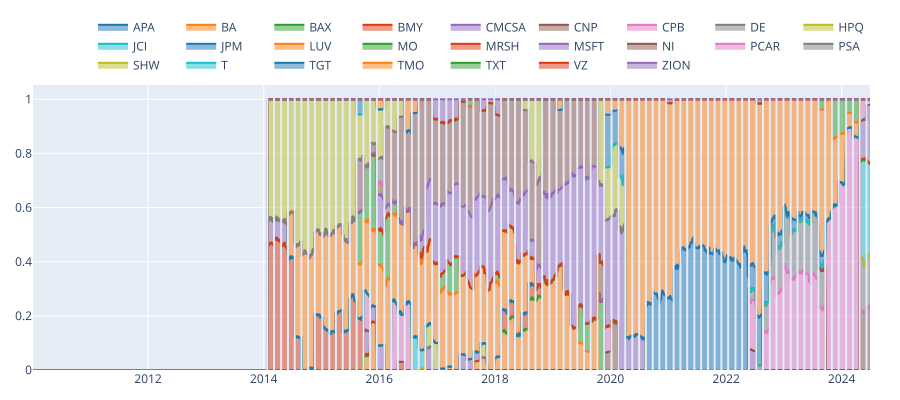

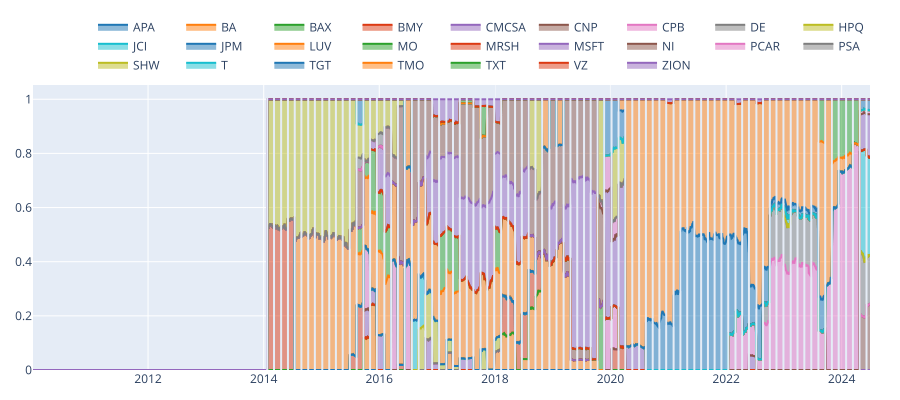

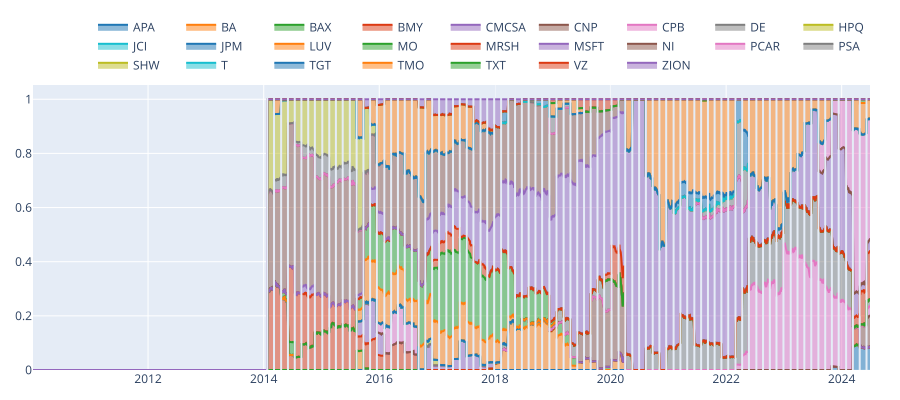

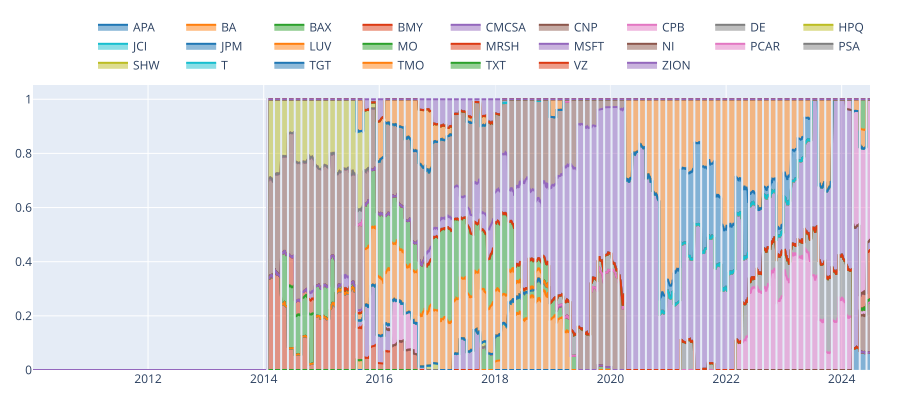

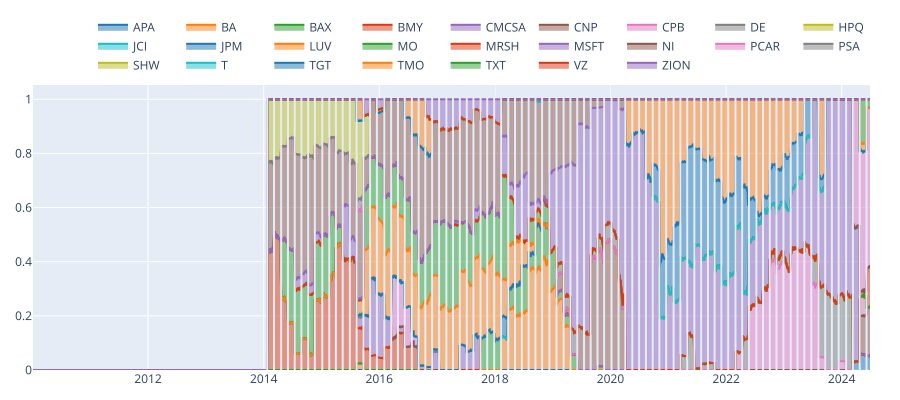

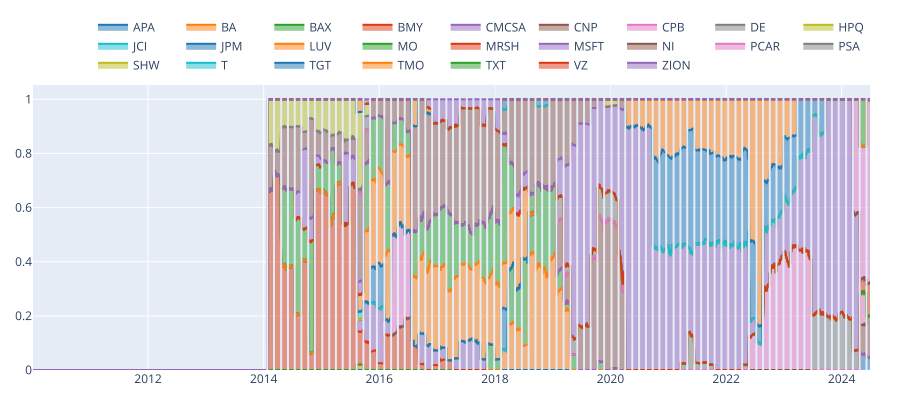

In [5]:
vbt.settings['plotting']['layout']['width'] = 900
vbt.settings['plotting']['layout']['height'] = 400

def plot_allocation(rb_pf):
    # Plot weights development of the portfolio
    rb_asset_value = rb_pf.asset_value(group_by=False)
    rb_value = rb_pf.value()
    rb_idxs = np.flatnonzero((rb_pf.asset_flow() != 0).any(axis=1))
    rb_dates = rb_pf.wrapper.index[rb_idxs]
    fig = (rb_asset_value.vbt / rb_value).vbt.plot(
        trace_names=assets,
        trace_kwargs=dict(
            stackgroup='one'
        )
    )
    for rb_date in rb_dates:
        fig.add_shape(
            dict(
                xref='x',
                yref='paper',
                x0=rb_date,
                x1=rb_date,
                y0=0,
                y1=1,
                line_color=fig.layout.template.layout.plot_bgcolor
            )
        )
    fig.show_svg()
    
for i in rms:
    plot_allocation(portfolio[i])

### 3.3 Plotting Portfolio Values

<Axes: >

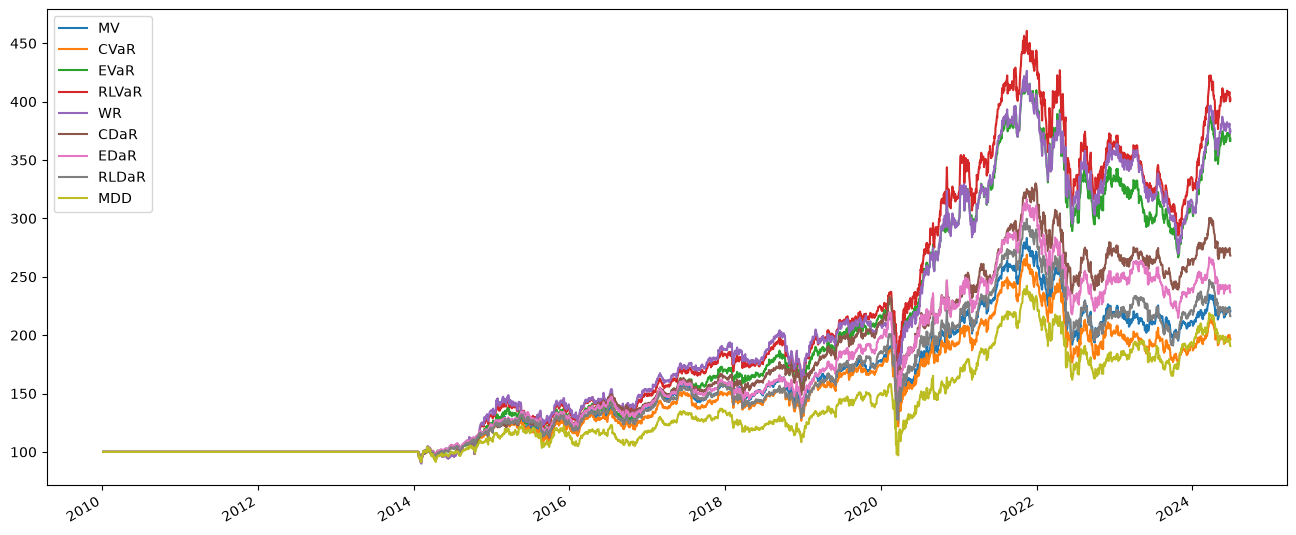

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,7))

values = pd.DataFrame([])
for i in rms:
    a = portfolio[i].value()
    values = pd.concat([values, a], axis=1)

values.columns = rms
values = pd.DataFrame(values)
values.plot(ax=ax)

### 3.4 Portfolio Stats

In [7]:
stats = pd.DataFrame([])
for i in rms:
    a = portfolio[i].stats()
    stats = pd.concat([stats, a], axis=1)

stats.columns = rms
display(stats)

,MV,CVaR,EVaR,RLVaR,WR,CDaR,EDaR,RLDaR,MDD
Start,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00,2010-01-04 00:00:00
End,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00,2024-06-28 00:00:00
Period,3646,3646,3646,3646,3646,3646,3646,3646,3646
Start Value,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
End Value,220.412481,196.603833,366.596612,401.068876,374.341755,268.203012,236.688248,216.267782,190.737812
Total Return [%],120.412481,96.603833,266.596612,301.068876,274.341755,168.203012,136.688248,116.267782,90.737812
Benchmark Return [%],345.215017,345.215017,345.215017,345.215017,345.215017,345.215017,345.215017,345.215017,345.215017
Max Gross Exposure [%],100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
Total Fees Paid,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Max Drawdown [%],34.700881,35.164781,37.179922,38.055222,36.810035,39.08815,36.771918,36.668345,38.568751
